In [ ]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
import sys
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(25)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# Configuracion para importar src
current_working_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_working_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

In [2]:
conexion = os.getenv("conexion_bbdd")
madrid_21 = feda.obtener_datos_madrid(conexion, 2021, 2021, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [3]:
df_mensual, estaciones, contaminantes = feda.preproceso_datos(madrid_21)

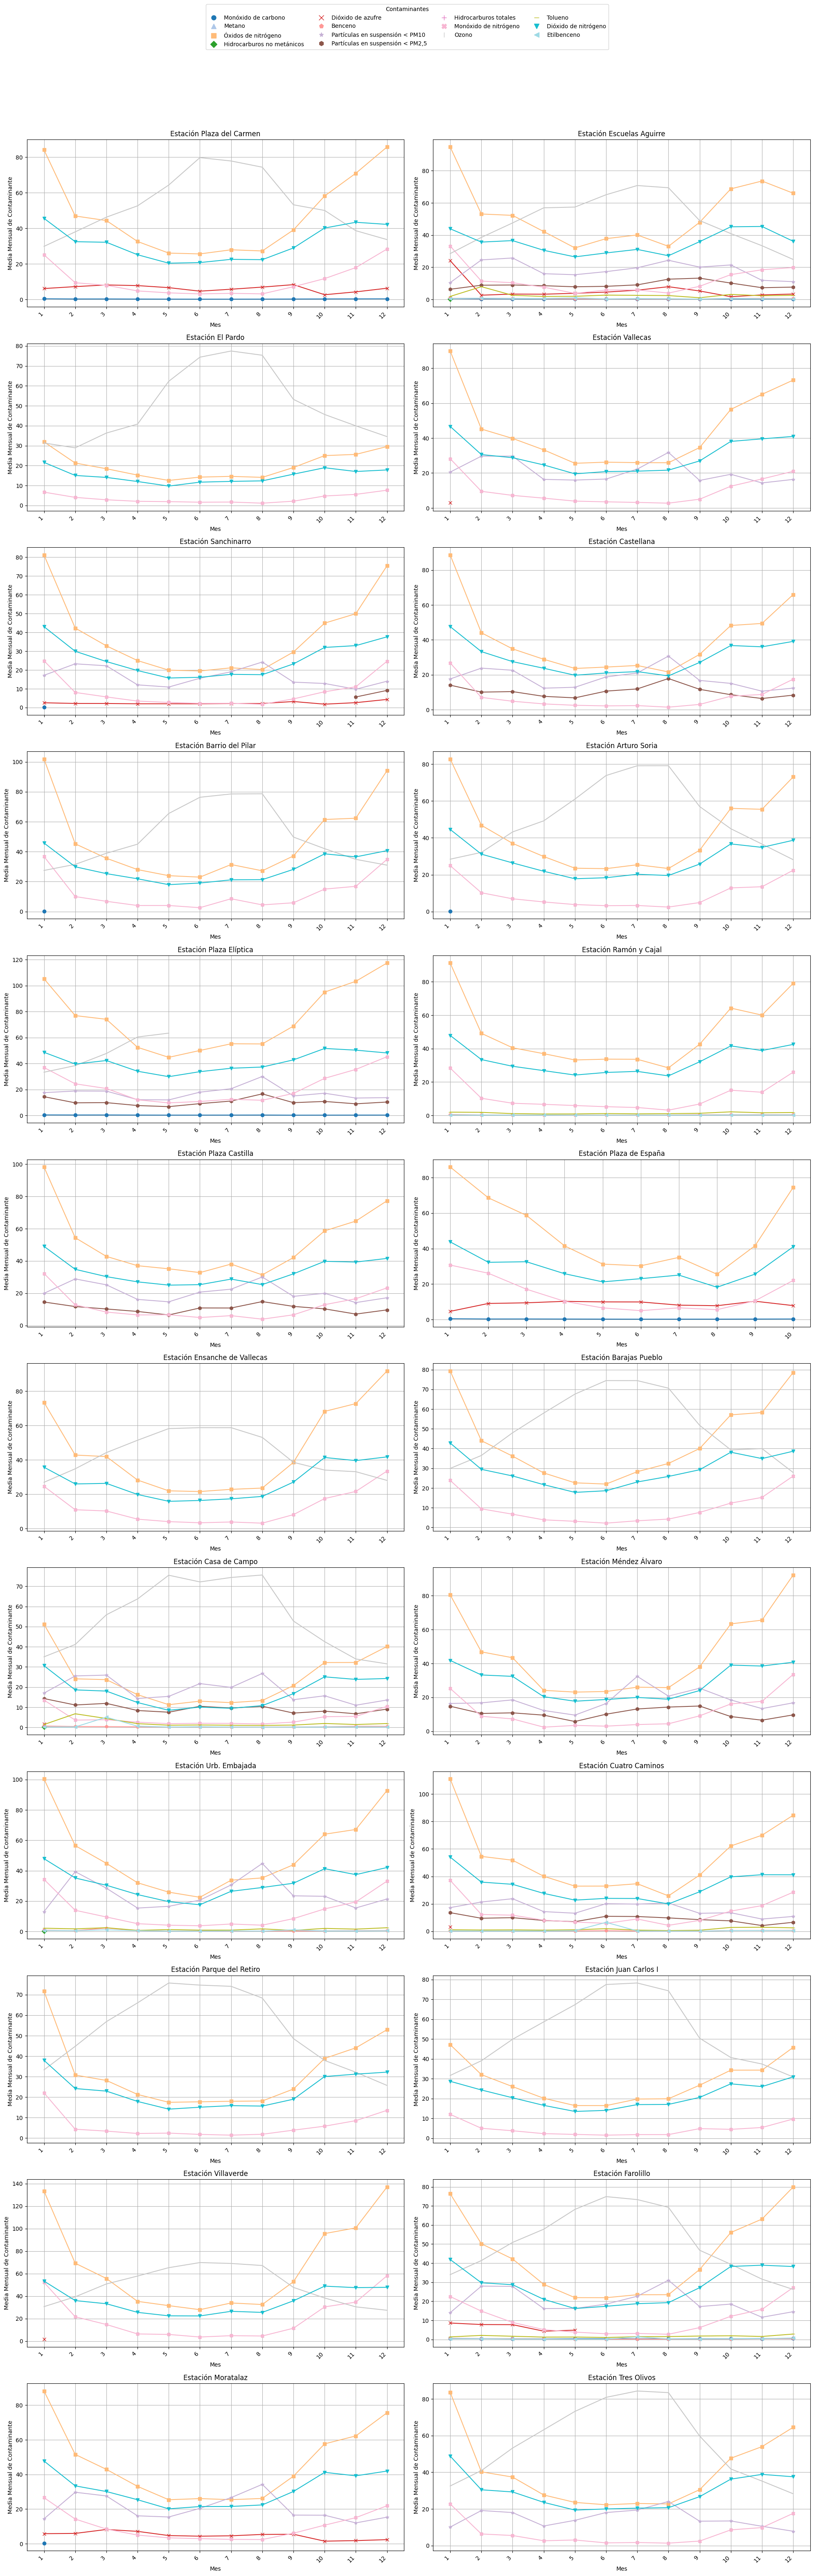

In [4]:
feda.graficos_estaciones(df_mensual, estaciones, contaminantes)

Analizamos los contaminantes que se miden en más estaciones, ya que son los que permiten mejor comparación entre ellas.

In [5]:
contaminantes_por_estacion = (
    madrid_21.group_by("contaminante")
    .agg(pl.col("estacion").n_unique().alias("num_estaciones"))
    .sort("num_estaciones", descending=True)  # Opcional, para ordenar de mayor a menor
)
contaminantes_por_estacion

contaminante,num_estaciones
str,u32
"""Dióxido de nitrógeno""",24
"""Óxidos de nitrógeno""",24
"""Monóxido de nitrógeno""",24
"""Ozono""",14
"""Partículas en suspensión < PM1…",13
"""Dióxido de azufre""",10
"""Monóxido de carbono""",10
"""Partículas en suspensión < PM2…",8
"""Benceno""",6


Todos los  **Óxidos de nitrógeno** siguen un patrón muy similar en todas las estaciones, con un descenso marcado de enero a marzo, una cierta estabilidad ente marzo y agosto y otra subida en octubre.
El **Ozono**, se mide en 14 de las 24 estaciones y, en las estaciones que lo miden tiene un patrón opuesto al de todos los óxidos de nitrógeno: mínimos en enero y diciembre y máximos en torno a julio - agosto.  Además este año también se aprecia el patrón opuesto en octubre - noviembre, mientras que los óxidos de nitrógeno suben en octubre, caen en noviembre y vuelven a subir en diciembre, el ozono cae en octubre, sube en noviembre y vuelve a caer en diciembre.
El siguiente que aparece en más estaciones es **Partículas en suspensión < PM10** que en este año presenta picos en febrero-marzo y agosto, siendo el de agosto el mayor.   
El **monóxido de carbono** se mide en 10 estaciones aunque parece tener un valor muy cercano a 0 en todas las estaciones todo el año. Parece que en algunas estaciones solo hay valores para enero. Puede ser que se dejara de medir o que haya error en los datos.
El **dióxido de azufre** también se mide en 10 estaciones y aunque se mantiene relativamente en niveles bajos.  
Como dato a destacar, parece que se han modificado los contaminante medidos en varias estaciones.
